In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv('50_Startups.csv')

In [3]:
dataset.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [4]:
dataset = pd.get_dummies(dataset,drop_first = True)

In [5]:
dataset = dataset.astype(int)

In [6]:
dataset.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349,136897,471784,192261,0,1
1,162597,151377,443898,191792,0,0
2,153441,101145,407934,191050,1,0
3,144372,118671,383199,182901,0,1
4,142107,91391,366168,166187,1,0


In [7]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [8]:
Independent = dataset[['R&D Spend', 'Administration', 'Marketing Spend',
       'State_Florida', 'State_New York']]

In [9]:
Independent.head()

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349,136897,471784,0,1
1,162597,151377,443898,0,0
2,153441,101145,407934,1,0
3,144372,118671,383199,0,1
4,142107,91391,366168,1,0


In [10]:
dependent = dataset[['Profit']]

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(Independent,dependent,test_size = 0.30,random_state=0)

In [12]:
#Standerdization i am going because to improve my model perforamnce
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [13]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(criterion='squared_error',splitter='random',max_features='log2',random_state = 0)
regressor = regressor.fit(X_train,y_train)

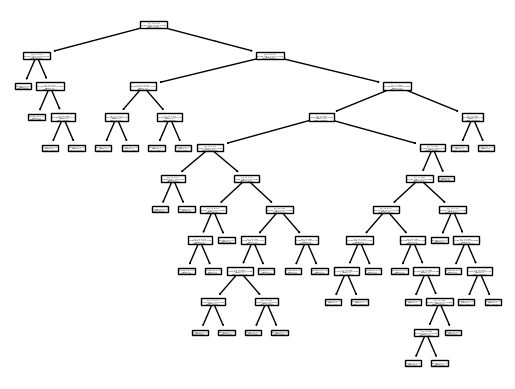

In [14]:
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [15]:
y_pred = regressor.predict(X_test)

In [16]:
from sklearn.metrics import r2_score
r_score = r2_score(y_test,y_pred)

In [17]:
r_score

0.7055032308605016